Attempting Different Feature Selection Methods

In [1]:
FIGURES_DIR = "C:\\dev\\Paddy_Prediction\\reports"
PROCESSED_DIR = "data/processed"
RANDOM_SEED = 42

In [2]:
import pandas as pd

data = r"C:\dev\Paddy_Prediction\data\transformed\paddy_preprocessed_tree.csv"
df = pd.read_csv(data)
df.head()

,LP_Mainfield(in Tonnes),Urea_40Days,Potassh_50Days,30DRain( in mm),30DAI(in mm),30_50DRain( in mm),30_50DAI(in mm),51_70DRain(in mm),51_70AI(in mm),71_105DRain(in mm),...,Wind Direction_D61_D90_NNE,Wind Direction_D61_D90_NNW,Wind Direction_D61_D90_SE,Wind Direction_D61_D90_SW,Wind Direction_D91_D120_NW,Wind Direction_D91_D120_S,Wind Direction_D91_D120_SSE,Wind Direction_D91_D120_W,Wind Direction_D91_D120_WSW,Paddy yield(in Kg)
0,1.587832,1.587832,1.587832,1.361570,-1.361570,1.381531,-1.381531,1.235600,-1.235600,1.381531,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,35028
1,1.587832,1.587832,1.587832,1.361570,-1.361570,1.381531,-1.381531,1.235600,-1.235600,1.381531,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,35412
2,1.587832,1.587832,1.587832,-0.347370,0.347370,-0.953675,0.953675,-1.270003,1.270003,-0.953675,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,36300
3,1.587832,1.587832,1.587832,-0.347370,0.347370,-0.953675,0.953675,-1.270003,1.270003,-0.953675,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,35016
4,1.587832,1.587832,1.587832,-0.968802,0.968802,-0.486634,0.486634,-0.090896,0.090896,-0.486634,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,34044


In [3]:
#Split features target
X = df.drop(columns=["Paddy yield(in Kg)"])
y = df["Paddy yield(in Kg)"]
X, y

(      LP_Mainfield(in Tonnes)  Urea_40Days  Potassh_50Days  30DRain( in mm)  \
 0                    1.587832     1.587832        1.587832         1.361570   
 1                    1.587832     1.587832        1.587832         1.361570   
 2                    1.587832     1.587832        1.587832        -0.347370   
 3                    1.587832     1.587832        1.587832        -0.347370   
 4                    1.587832     1.587832        1.587832        -0.968802   
 ...                       ...          ...             ...              ...   
 2784                -1.890383    -1.890383       -1.890383        -0.347370   
 2785                -1.890383    -1.890383       -1.890383        -0.968802   
 2786                -1.890383    -1.890383       -1.890383        -0.968802   
 2787                -1.890383    -1.890383       -1.890383         1.361570   
 2788                -1.890383    -1.890383       -1.890383         1.361570   
 
       30DAI(in mm)  30_50DRain( in mm

### Using Pearson Correlation to check and drop redundant fatures if any

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

In [5]:
IMPORTANT_FEATURES = [
    "Hectares ",
    "Urea_40Days",
    "Pest_60Day(in ml)",
    "Weed28D_thiobencarb"
]

In [6]:
def detect_ohe_columns(X):
    ohe_cols = []

    for col in X.columns:
        # Pattern-based detection
        if any(prefix in col for prefix in ["Wind Direction", "Agriblock", "Variety", "Soil Type", "Nursery"]):
            ohe_cols.append(col)
        # Value-based fallback
        elif set(X[col].dropna().unique()).issubset({0, 1}) and X[col].nunique() <= 2:
            ohe_cols.append(col)

    return ohe_cols


In [7]:
def remove_correlated_features(X: pd.DataFrame, threshold: float = 0.90):
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

    # Detect OHE features that are not to dropped
    ohe_cols = detect_ohe_columns(X)

    # Keep only continuous numeric features
    continuous_cols = [col for col in numeric_cols if col not in ohe_cols]

    print(f"[INFO] OHE Features Detected: {len(ohe_cols)}")
    print(f"[INFO] Continuous Features Used for Correlation: {len(continuous_cols)}")

    # Correlation only on continuous features
    corr_matrix = X[continuous_cols].corr().abs()

    # Heatmap 
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    sns.heatmap(
        corr_matrix, mask=mask, cmap="coolwarm", center=0.5,
        linewidths=0.3, cbar_kws={"shrink": 0.7}, annot=False
    )

    # Upper triangle
    upper_tri = corr_matrix.where(mask == False)

    to_drop = set()

    for col in upper_tri.columns:
        correlated_with = upper_tri.index[upper_tri[col] > threshold].tolist()

        if correlated_with:
            candidates = correlated_with + [col]
            mean_corrs = corr_matrix[candidates].mean()
            worst = mean_corrs.idxmax()
            to_drop.add(worst)

    # Remove any features marked as important (if defined)
    if 'IMPORTANT_FEATURES' in globals():
        to_drop = to_drop - set(IMPORTANT_FEATURES)

    to_drop = list(to_drop)

    print(f"[Pearson Threshold = {threshold}]")
    print(f"Dropped {len(to_drop)} correlated features: {to_drop}")

    # Drop only from continuous features
    X_filtered = X.drop(columns=to_drop)

    return X_filtered, to_drop, ohe_cols

[INFO] OHE Features Detected: 28
[INFO] Continuous Features Used for Correlation: 35
[Pearson Threshold = 0.9]
Dropped 7 correlated features: ['30_50DRain( in mm)', 'Inst Wind Speed_D31_D60(in Knots)', '71_105DRain(in mm)', '71_105DAI(in mm)', 'Min temp_D1_D30', 'Max temp_D91_D120', 'LP_nurseryarea(in Tonnes)']
Dropped 7 correlated features
Detected 28 OHE-style columns


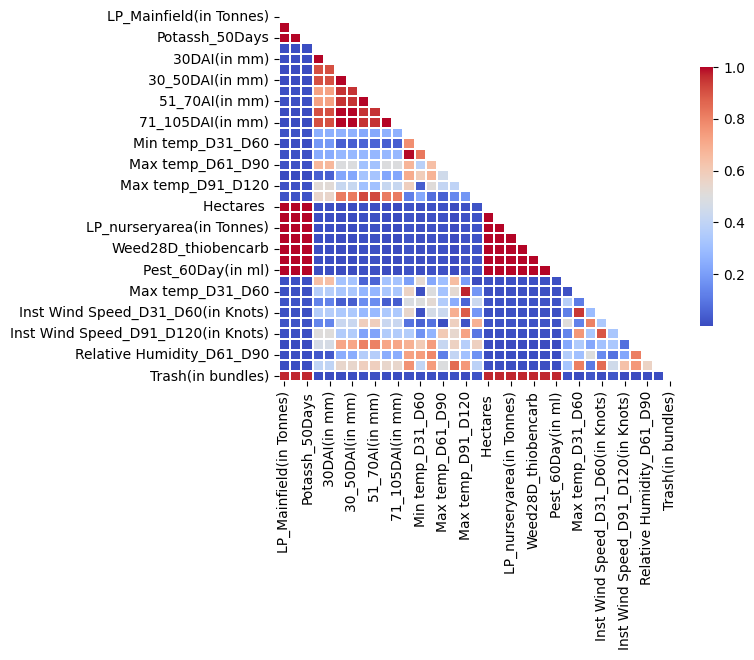

In [8]:
X, dropped_features, ohe_cols = remove_correlated_features(X, threshold=0.90)
print(f"Dropped {len(dropped_features)} correlated features")
print(f"Detected {len(ohe_cols)} OHE-style columns")

**Pre Filter / Redundancy removal with Pearson Report**:

Important features that could play a major role in Paddy Yield (such as Hectares) was tracked to NOT be dropped. One-hot encoded categorical featured were tracked to be dropped before this pearson correlation test, so that this feature selection can only run on continuous values.

Pearson correlation removed features that are redundant as they highly correlate with each other. For example, redundant time windows in this dataset were removed, so was temperature windows, and wind speed

**Removed 7 features**

In [29]:
print(f"Original feature count: {len(df.columns) - 1}")  # Exclude target
print(f"Remaining feature count after dropping correlated features: {X.shape[1]}")


Original feature count: 63
Remaining feature count after dropping correlated features: 56


#### Implementing Random Forest Feature Importance

In [11]:
from sklearn.ensemble import RandomForestRegressor

In [30]:
def random_forest_importance(X, y, top_n=20):
    """
    Train Random Forest and return top important features.
    """


    # Train model
    model = RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_SEED,
        n_jobs=-1
    )
    model.fit(X, y)

    # Get feature importance
    importance = pd.Series(
        model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)

    # Select top features
    top_features = importance.head(top_n)

    print(f"\nTop {top_n} features selected")

    # Plot
    plt.figure(figsize=(10, 6))
    top_features.sort_values().plot(kind="barh")
    plt.title("Random Forest Feature Importance")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/feature_importance.png")
    plt.close()

    return top_features.index.tolist(), importance

In [31]:
rf_features, rf_importances = random_forest_importance(X, y)


Top 20 features selected


In [32]:
rf_features

['Potassh_50Days',
 'Nursery area (Cents)',
 'Urea_40Days',
 'LP_Mainfield(in Tonnes)',
 'Micronutrients_70Days',
 'Pest_60Day(in ml)',
 'Seedrate(in Kg)',
 'Trash(in bundles)',
 'DAP_20days',
 'Hectares ',
 'Weed28D_thiobencarb',
 'Nursery_wet',
 'Soil Types_clay',
 'Variety_ponmani',
 'Variety_delux ponni',
 'Max temp_D61_D90',
 'Inst Wind Speed_D1_D30(in Knots)',
 'Relative Humidity_D1_D30',
 'Min temp_D31_D60',
 'Max temp_D1_D30']

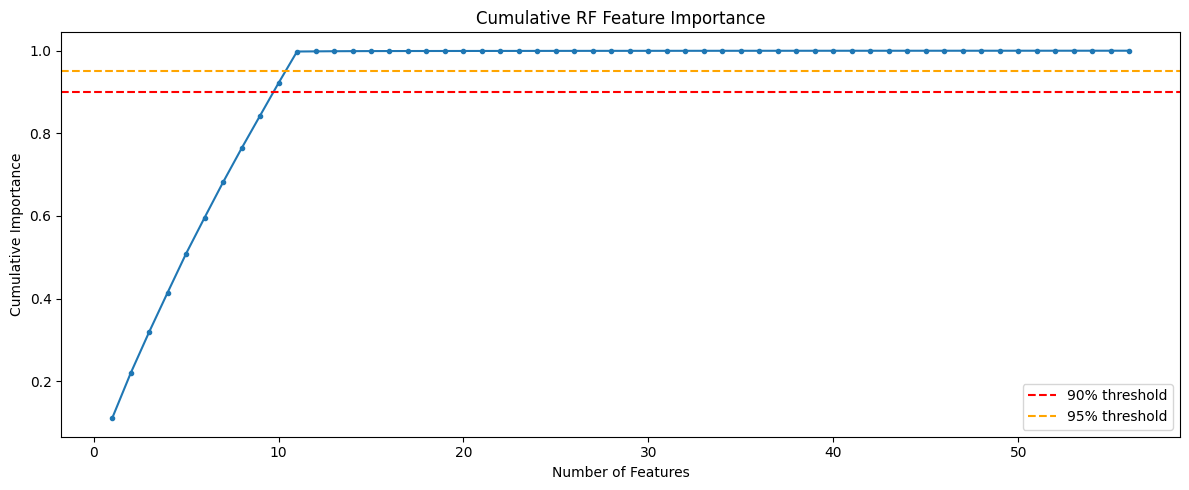

Features needed for 90% importance: 10
Features needed for 95% importance: 11


In [33]:
# Checking how many features are enough by sorting importance in descending order and looking at cumulative importance

import matplotlib.pyplot as plt

cumulative = rf_importances.sort_values(ascending=False).cumsum()

plt.figure(figsize=(12, 5))
plt.plot(range(1, len(cumulative) + 1), cumulative.values, marker='o', markersize=3)
plt.axhline(y=0.90, color='red', linestyle='--', label='90% threshold')
plt.axhline(y=0.95, color='orange', linestyle='--', label='95% threshold')
plt.xlabel("Number of Features")
plt.ylabel("Cumulative Importance")
plt.title("Cumulative RF Feature Importance")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/cumulative_importance.png", dpi=150)
plt.show()

# Print how many features needed for 90% and 95%
n_90 = (cumulative < 0.90).sum() + 1
n_95 = (cumulative < 0.95).sum() + 1
print(f"Features needed for 90% importance: {n_90}")
print(f"Features needed for 95% importance: {n_95}")

In [38]:
# Select top 11 features (95% cumulative importance)
final_features = rf_importances.sort_values(ascending=False).head(11).index.tolist()

print("Final selected features:")
for i, f in enumerate(final_features, 1):
    print(f"  {i}. {f}")

Final selected features:
  1. Potassh_50Days
  2. Nursery area (Cents)
  3. Urea_40Days
  4. LP_Mainfield(in Tonnes)
  5. Micronutrients_70Days
  6. Pest_60Day(in ml)
  7. Seedrate(in Kg)
  8. Trash(in bundles)
  9. DAP_20days
  10. Hectares 
  11. Weed28D_thiobencarb


### Other feature selection methods

In [40]:
from sklearn.inspection import permutation_importance

rf_model = RandomForestRegressor(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)
rf_model.fit(X, y)

perm = permutation_importance(rf_model, X, y, n_repeats=10, random_state=RANDOM_SEED, n_jobs=-1)

perm_series = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
print(perm_series.head(20))

Micronutrients_70Days               0.030890
Potassh_50Days                      0.026066
Nursery area (Cents)                0.023401
Seedrate(in Kg)                     0.022651
Hectares                            0.021789
Urea_40Days                         0.021621
Weed28D_thiobencarb                 0.020703
DAP_20days                          0.020413
Pest_60Day(in ml)                   0.015748
LP_Mainfield(in Tonnes)             0.015747
Trash(in bundles)                   0.011281
Soil Types_clay                     0.001115
Nursery_wet                         0.000979
Variety_ponmani                     0.000509
Variety_delux ponni                 0.000149
Max temp_D61_D90                    0.000040
Inst Wind Speed_D1_D30(in Knots)    0.000038
Relative Humidity_D1_D30            0.000030
Min temp_D31_D60                    0.000018
Min temp_D61_D90                    0.000013
dtype: float64


Permutation importance confirms that paddy yield in this dataset is 
almost entirely determined by farm input quantities and land scale. 
Weather features show near-zero importance (0.00001–0.001), likely 
due to low climate variability across farms in the same Tamil Nadu 
region and season. Final 15 features selected: 11 farm inputs + 
soil type, nursery type, and crop variety.

In [41]:
final_features = perm_series.head(15).index.tolist()

df_final = X[final_features].copy()
df_final["Paddy yield(in Kg)"] = y.values
df_final.to_csv("../data/transformed/rf_selected_features.csv", index=False)

print(f"Final feature set: {len(final_features)} features")
print(f"Saved dataset shape: {df_final.shape}")

Final feature set: 15 features
Saved dataset shape: (2789, 16)


In [42]:
df_final.head(5)

,Micronutrients_70Days,Potassh_50Days,Nursery area (Cents),Seedrate(in Kg),Hectares,Urea_40Days,Weed28D_thiobencarb,DAP_20days,Pest_60Day(in ml),LP_Mainfield(in Tonnes),Trash(in bundles),Soil Types_clay,Nursery_wet,Variety_ponmani,Variety_delux ponni,Paddy yield(in Kg)
0,90.0,1.587832,120.0,150.0,6.0,1.587832,12.0,240.0,3600.0,1.587832,540.0,0.0,0.0,0.0,0.0,35028
1,90.0,1.587832,120.0,150.0,6.0,1.587832,12.0,240.0,3600.0,1.587832,600.0,1.0,1.0,1.0,0.0,35412
2,90.0,1.587832,120.0,150.0,6.0,1.587832,12.0,240.0,3600.0,1.587832,600.0,0.0,0.0,0.0,1.0,36300
3,90.0,1.587832,120.0,150.0,6.0,1.587832,12.0,240.0,3600.0,1.587832,540.0,1.0,1.0,0.0,0.0,35016
4,90.0,1.587832,120.0,150.0,6.0,1.587832,12.0,240.0,3600.0,1.587832,600.0,0.0,0.0,1.0,0.0,34044
